# Student Placement Prediction System — End-to-End ML Pipeline

**Objective:** Build a machine learning pipeline to predict whether a student will be
placed or not, based on academic performance, skills, and profile data.

**Pipeline stages:** EDA → Preprocessing → Feature Engineering → Model Building →
Model Optimization → Deployment (Streamlit)

## Phase 1: Business Understanding

**Problem statement:** Colleges and training institutes want to identify, ahead of
placement season, which students are at risk of not being placed so that career
services can target mentoring, mock interviews, and skill workshops at those students.

**Objective:** Predict `Placement_Status` (Placed / Not Placed) from a student's
academic record, test scores, and profile — using only information that is known
**before** placement outcomes occur.

**Business impact:**
- **For colleges:** prioritize placement-cell effort and resources toward at-risk students.
- **For HR/training partners:** benchmark which skills (coding, aptitude, communication)
  most strongly predict employability, to guide curriculum design.
- **For students:** get an early, data-driven signal of readiness with actionable feedback.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG_DIR = "figures"
RANDOM_STATE = 42

## Phase 2: Data Understanding & EDA

In [2]:
df = pd.read_csv("data/Student_Placement_Dataset_10000.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 26)


,Student_ID,Gender,Age,State,City,College_Type,Degree_Stream,10th_Percentage,12th_Percentage,Graduation_Percentage,...,Certifications,Aptitude_Score,Coding_Score,Communication_Score,Technical_Score,Mock_Interview_Score,Resume_Score,Company_Type,Placement_Package_LPA,Placement_Status
0,SP100001,Male,20,Delhi,Jaipur,Private,BCA,97,67,65,...,3,83,99,46,84,54,72,Product,12.03,Placed
1,SP100002,Female,20,Gujarat,Bhopal,Autonomous,B.Sc,98,60,94,...,5,53,73,48,41,94,62,NaN,0.00,Not Placed
2,SP100003,Male,26,Rajasthan,Bengaluru,Private,MCA,55,85,68,...,3,76,54,43,35,95,46,NaN,0.00,Not Placed
3,SP100004,Female,22,Delhi,Delhi,Government,BCA,73,72,63,...,4,78,51,66,50,99,80,Startup,13.32,Placed
4,SP100005,Female,26,Rajasthan,Chennai,Private,BBA,67,54,63,...,3,53,93,85,88,87,75,MNC,11.08,Placed


In [3]:
print("Data types:\n")
print(df.dtypes)

Data types:

Student_ID                   str
Gender                       str
Age                        int64
State                        str
City                         str
College_Type                 str
Degree_Stream                str
10th_Percentage            int64
12th_Percentage            int64
Graduation_Percentage      int64
CGPA                     float64
Backlogs                   int64
Attendance                 int64
Internship                   str
Internship_Months          int64
Projects                   int64
Certifications             int64
Aptitude_Score             int64
Coding_Score               int64
Communication_Score        int64
Technical_Score            int64
Mock_Interview_Score       int64
Resume_Score               int64
Company_Type                 str
Placement_Package_LPA    float64
Placement_Status             str
dtype: object


In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:\n")
print(missing if len(missing) else "No missing values in raw form.")

Columns with missing values:

Company_Type    3976
dtype: int64


**Note on `Company_Type` missing values:** every one of the 3,976 missing values in
`Company_Type` corresponds exactly to a `Not Placed` student. This isn't "missing data"
in the usual sense — a student who wasn't placed simply has no company to report.
The same logic explains `Placement_Package_LPA` being 0 for every `Not Placed` row.
**Both columns are only known *after* the outcome, so they are dropped before modeling
to avoid data leakage (see Phase 3).**

Placement_Status
Placed        6024
Not Placed    3976
Name: count, dtype: int64

Class balance: 60.2% Placed / 39.8% Not Placed


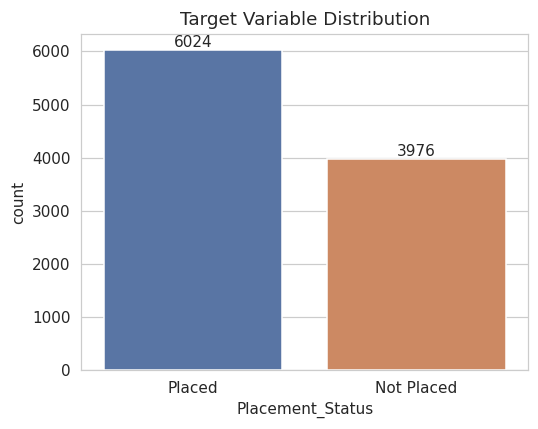

In [5]:
target_counts = df["Placement_Status"].value_counts()
print(target_counts)
print("\nClass balance: {:.1f}% Placed / {:.1f}% Not Placed".format(
    100 * target_counts["Placed"] / len(df), 100 * target_counts["Not Placed"] / len(df)))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Placement_Status", hue="Placement_Status",
              palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_title("Target Variable Distribution")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_target_distribution.png")
plt.show()

**Observation:** The dataset is mildly imbalanced — about 60% Placed vs 40% Not Placed
(roughly 1.5:1). This isn't severe enough to require SMOTE oversampling, but we account
for it using `class_weight="balanced"` during model training and tuning, and we report
Precision/Recall/F1 (not just Accuracy) since accuracy alone can be misleading on
imbalanced data.

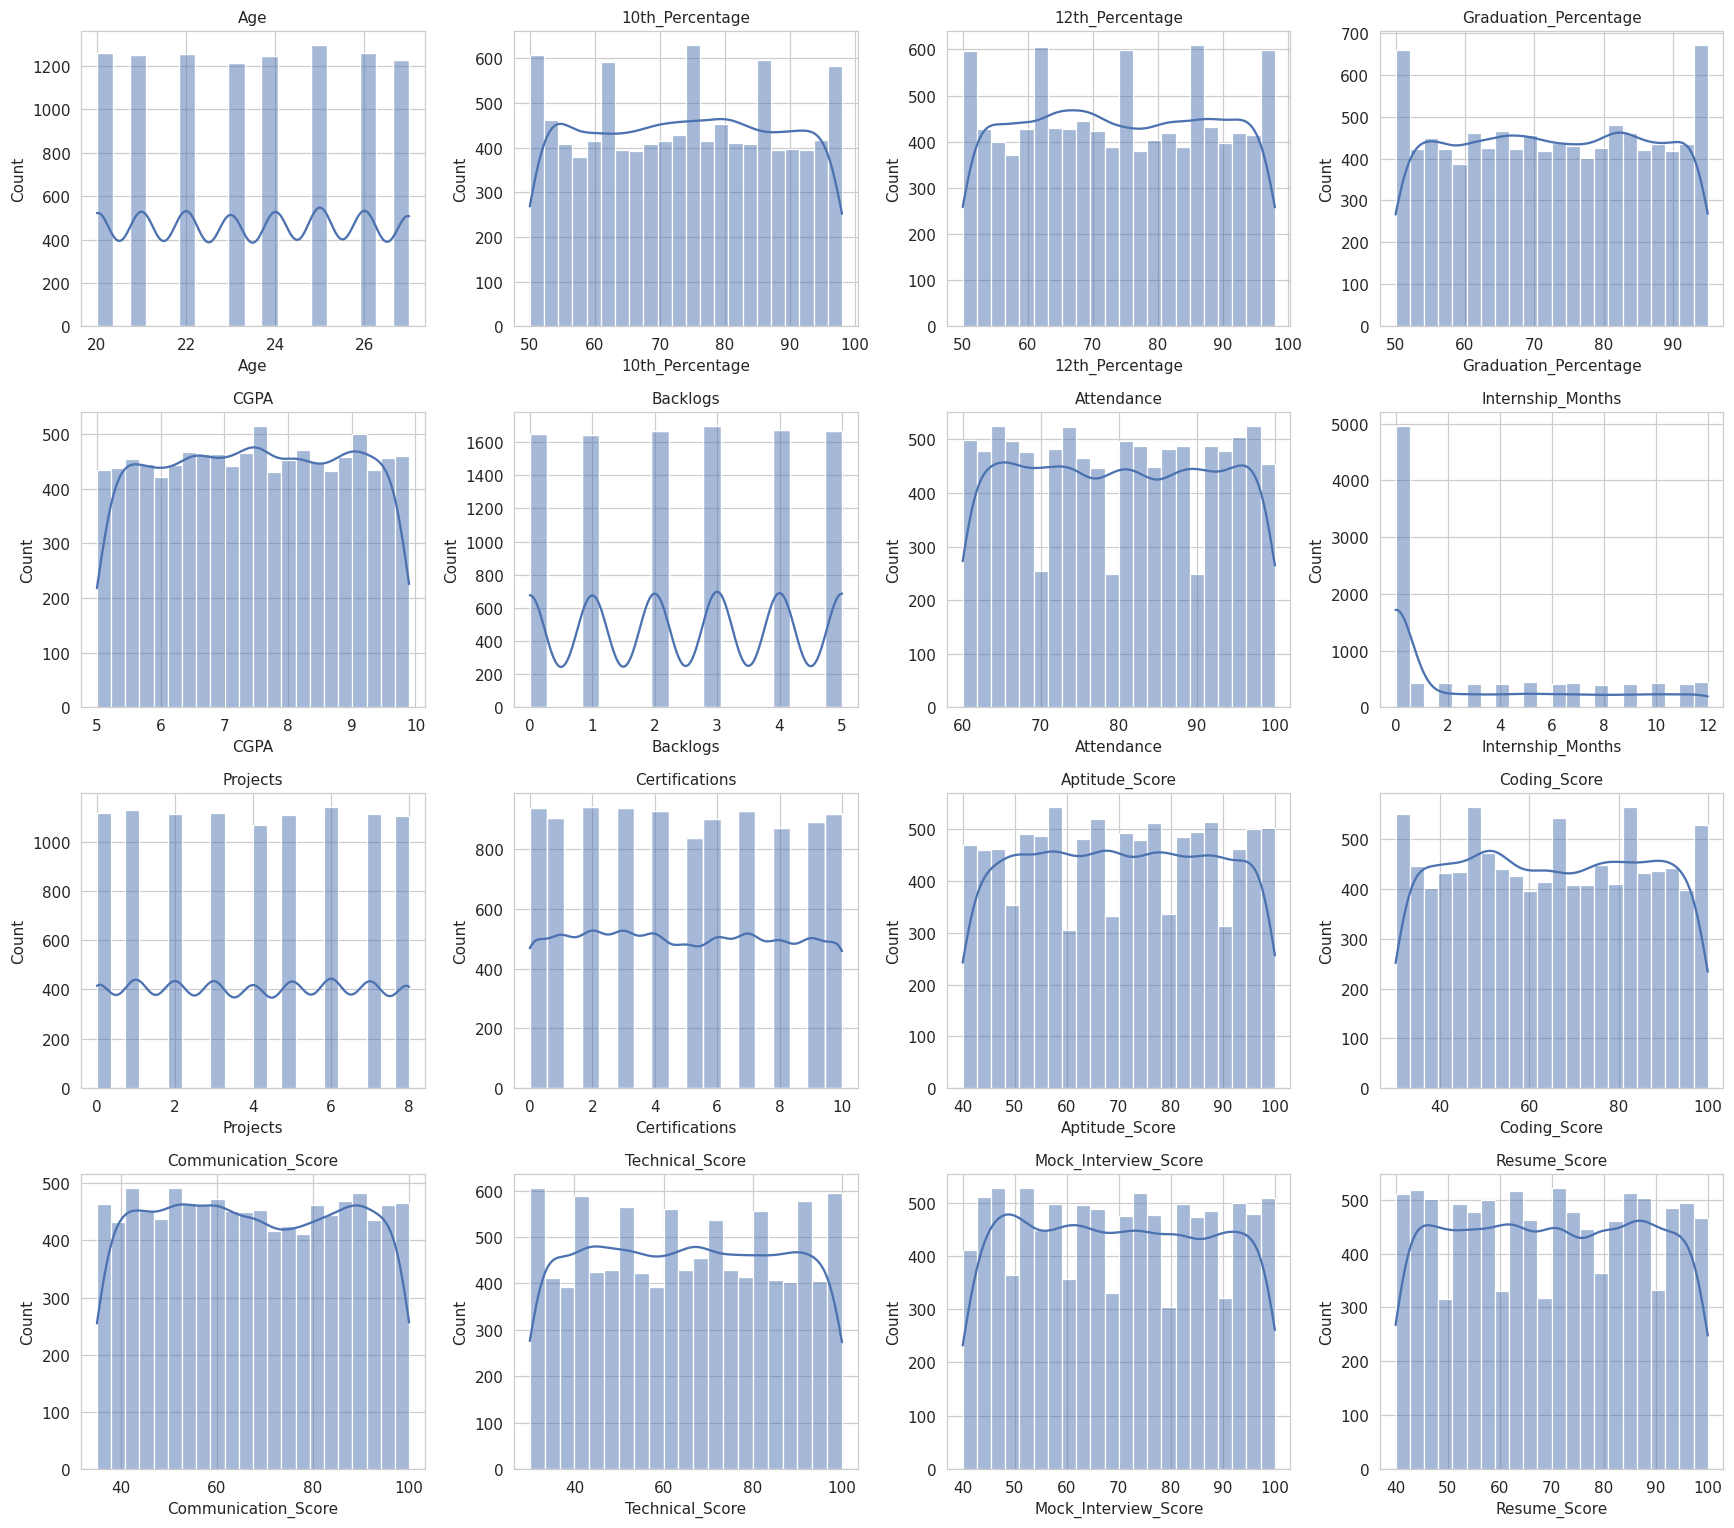

In [6]:
numeric_cols = ["Age", "10th_Percentage", "12th_Percentage", "Graduation_Percentage",
                 "CGPA", "Backlogs", "Attendance", "Internship_Months", "Projects",
                 "Certifications", "Aptitude_Score", "Coding_Score", "Communication_Score",
                 "Technical_Score", "Mock_Interview_Score", "Resume_Score"]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_numeric_distributions.png")
plt.show()

**Observation:** Most academic percentages, CGPA, and skill scores are roughly
uniformly/normally spread across their ranges (this is a synthetically generated
dataset), with no extreme skew. `Backlogs`, `Internship_Months`, `Projects`, and
`Certifications` are discrete counts with a handful of levels.

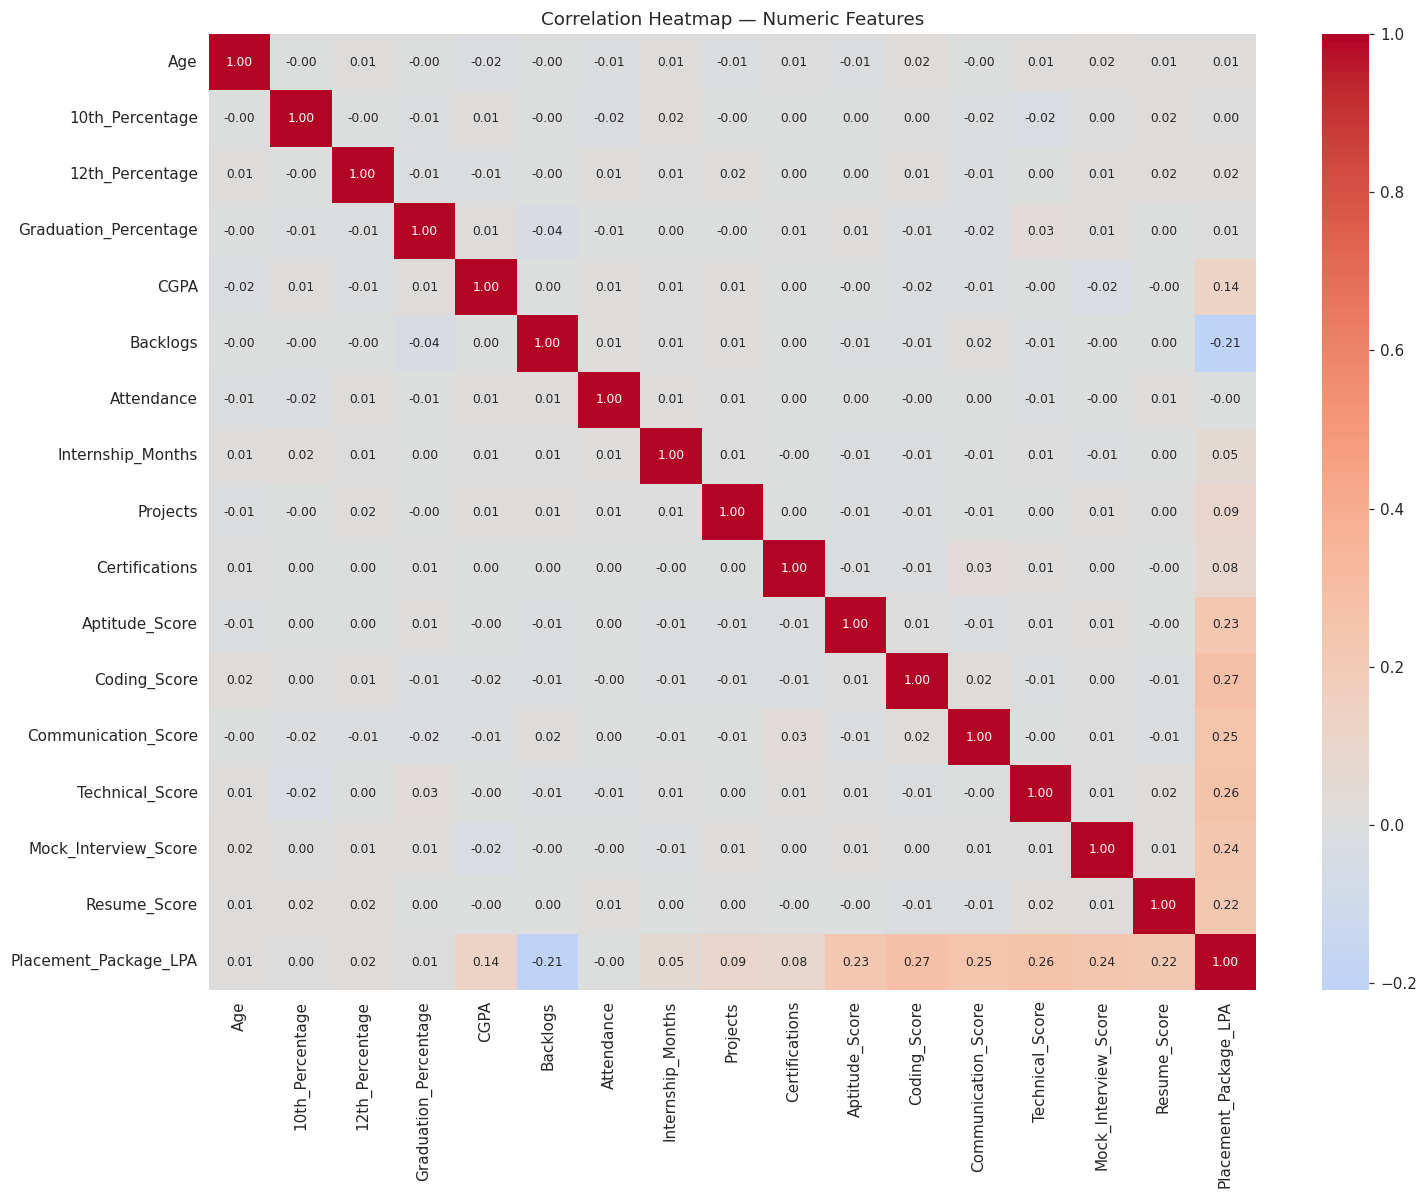

In [7]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df[numeric_cols + ["Placement_Package_LPA"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_correlation_heatmap.png")
plt.show()

**Observation:** No pair of *input* features is strongly correlated with another
(max off-diagonal ~0.05–0.10), which means there's little multicollinearity to worry
about. `Placement_Package_LPA` correlates with several skill scores, but as established
above it's a post-outcome field and will be excluded from the feature set.

Correlation of numeric features with Placement (1=Placed):

Coding_Score             0.321759
Technical_Score          0.319377
Communication_Score      0.299231
Mock_Interview_Score     0.283531
Aptitude_Score           0.273157
Resume_Score             0.264889
CGPA                     0.156686
Projects                 0.109383
Certifications           0.102093
Internship_Months        0.055949
12th_Percentage          0.016282
Age                      0.015456
Graduation_Percentage    0.015196
Attendance               0.006168
10th_Percentage          0.002025
Backlogs                -0.256023
Name: Placement_Status_Num, dtype: float64


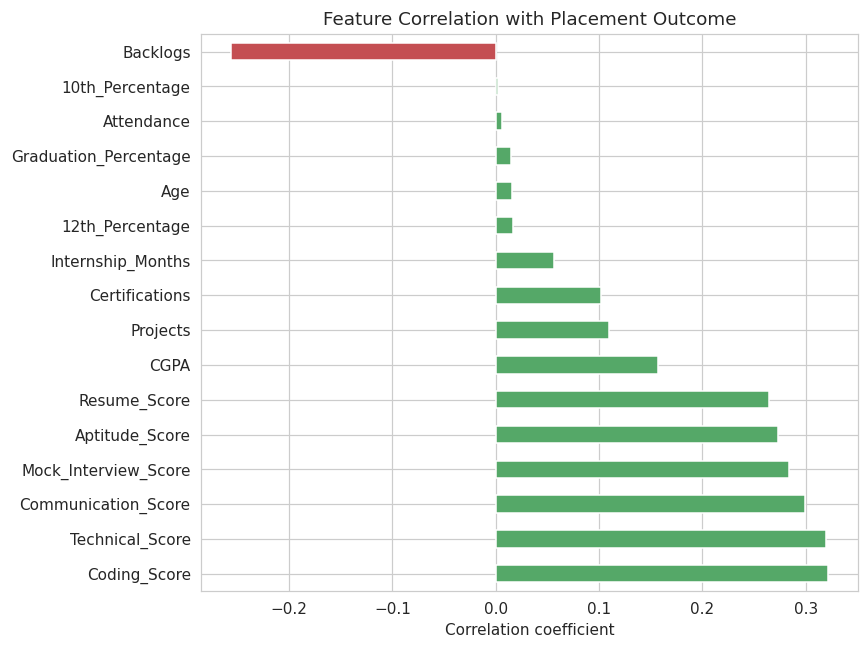

In [8]:
df_encoded_target = df.copy()
df_encoded_target["Placement_Status_Num"] = (df["Placement_Status"] == "Placed").astype(int)

corr_with_target = (
    df_encoded_target[numeric_cols + ["Placement_Status_Num"]]
    .corr()["Placement_Status_Num"]
    .drop("Placement_Status_Num")
    .sort_values(ascending=False)
)
print("Correlation of numeric features with Placement (1=Placed):\n")
print(corr_with_target)

fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.plot(kind="barh", ax=ax, color=(corr_with_target > 0).map({True: "#55A868", False: "#C44E52"}))
ax.set_title("Feature Correlation with Placement Outcome")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_correlation_with_target.png")
plt.show()

**Key question — which features influence placement most?**
`CGPA`, `Coding_Score`, `Technical_Score`, `Aptitude_Score`, and `Mock_Interview_Score`
show the strongest (positive) relationship with placement, while `Backlogs` shows a
negative relationship. Correlations are modest in absolute size (this is a synthetic,
fairly noisy dataset), which is why we rely on a Random Forest for a non-linear view
of importance in Phase 4, rather than correlation alone.

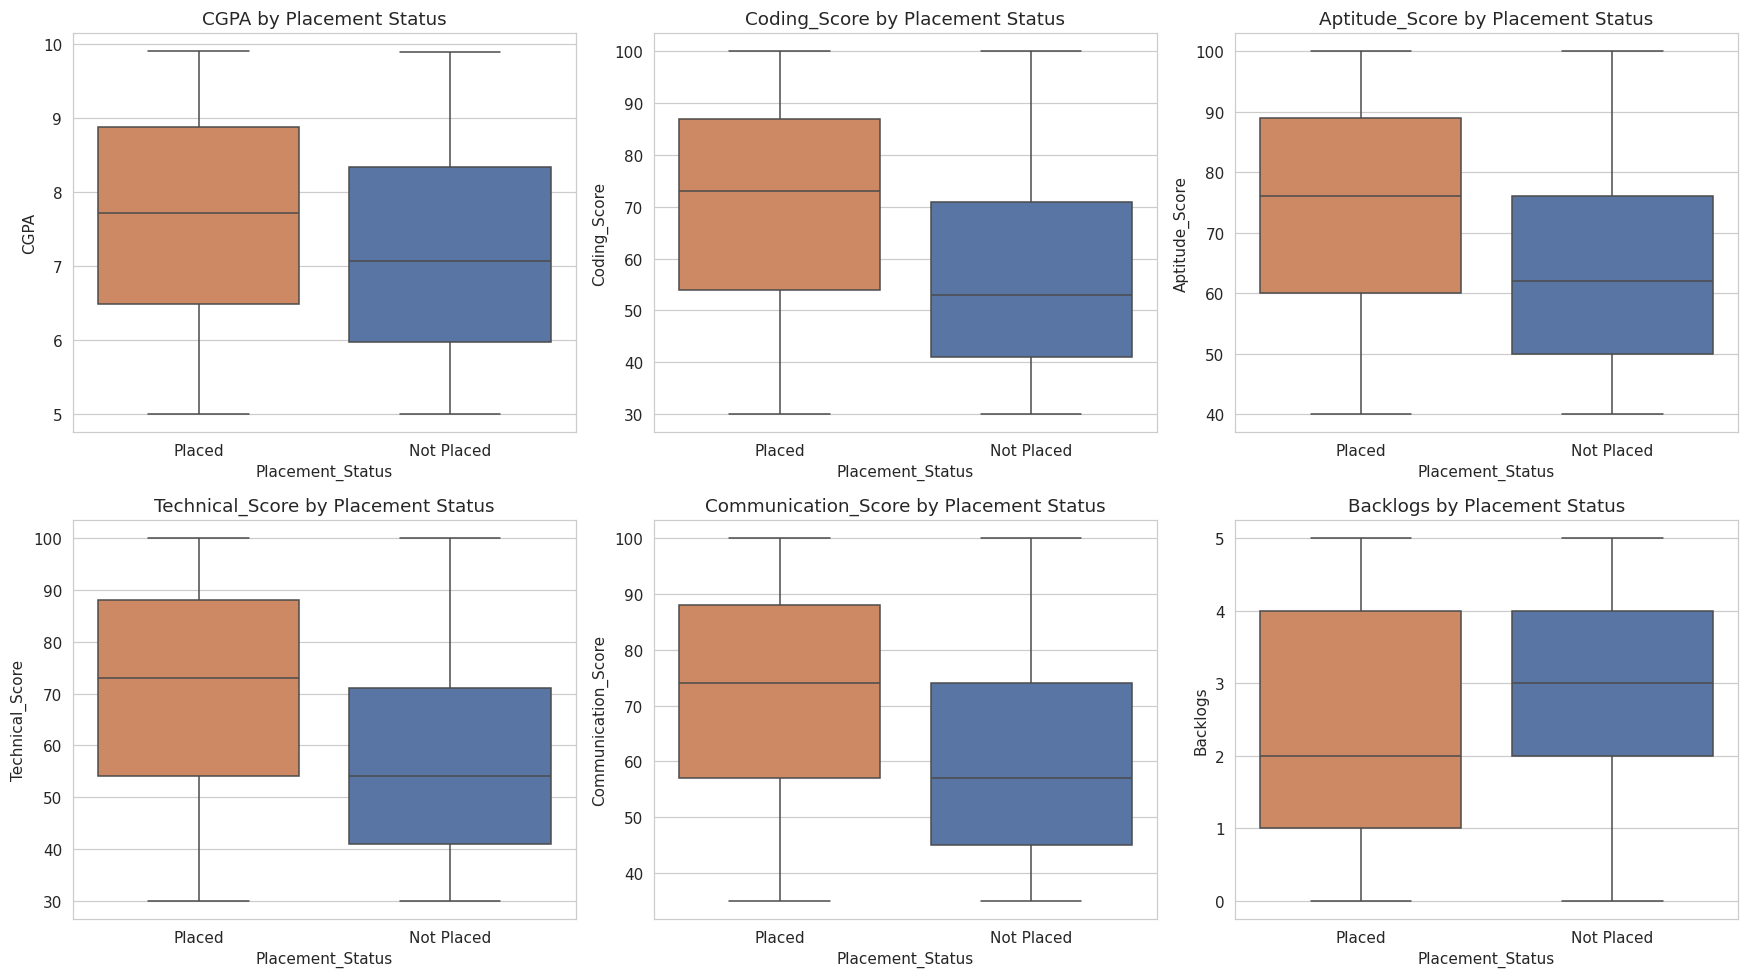

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
box_features = ["CGPA", "Coding_Score", "Aptitude_Score", "Technical_Score",
                 "Communication_Score", "Backlogs"]
for ax, col in zip(axes.ravel(), box_features):
    sns.boxplot(data=df, x="Placement_Status", y=col, hue="Placement_Status",
                palette=["#DD8452", "#4C72B0"], legend=False, ax=ax)
    ax.set_title(f"{col} by Placement Status")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_boxplots_vs_target.png")
plt.show()

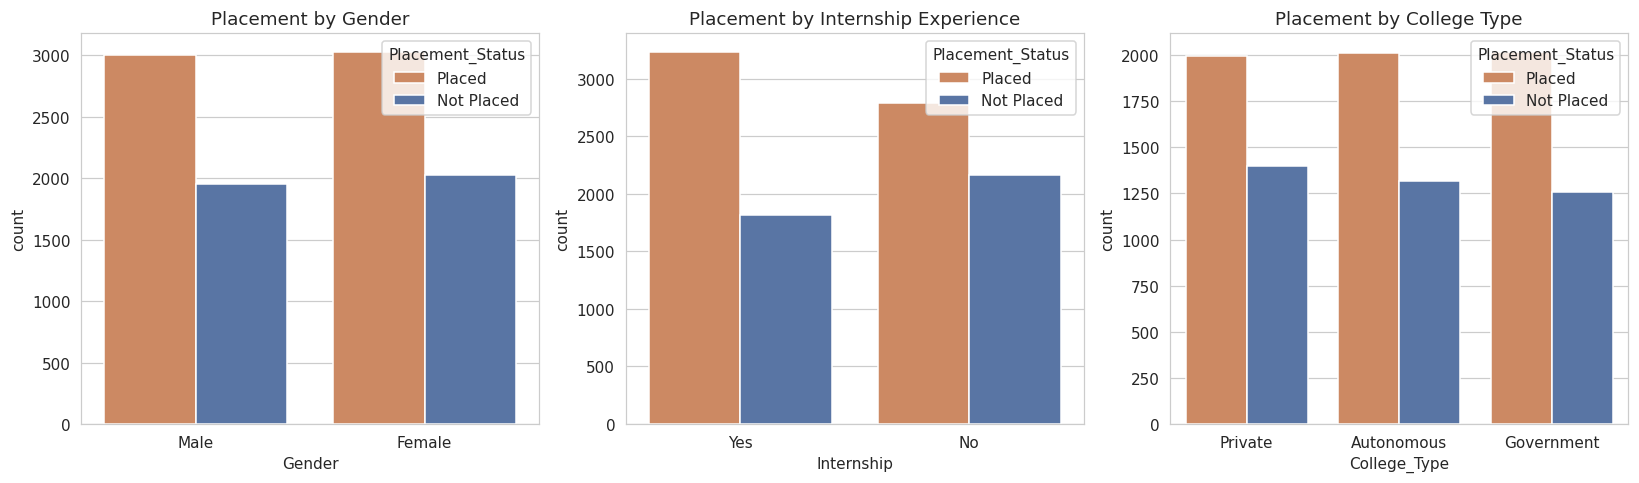

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=df, x="Gender", hue="Placement_Status", ax=axes[0],
              palette=["#DD8452", "#4C72B0"])
axes[0].set_title("Placement by Gender")
sns.countplot(data=df, x="Internship", hue="Placement_Status", ax=axes[1],
              palette=["#DD8452", "#4C72B0"])
axes[1].set_title("Placement by Internship Experience")
sns.countplot(data=df, x="College_Type", hue="Placement_Status", ax=axes[2],
              palette=["#DD8452", "#4C72B0"])
axes[2].set_title("Placement by College Type")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_categorical_vs_target.png")
plt.show()

**Observation:** Placement rates look broadly similar across `Gender` and
`College_Type`, i.e. these fields carry limited standalone signal. Students with
internship experience show a modest lift in placement rate, consistent with the
positive correlation seen for related score-based features. There is no visible sign
of unfair skew that would need correcting.

## Phase 3: Data Preprocessing

In [11]:
# 3a. Handle missing values
# Company_Type and Placement_Package_LPA are populated only *after* a student is placed
# (0 missing/0-valued for "Not Placed" by construction) — using them as predictors would
# leak the target directly into the model, so both are dropped. Student_ID is a unique
# identifier with no predictive value and is dropped too.
LEAKAGE_COLS = ["Company_Type", "Placement_Package_LPA"]
ID_COLS = ["Student_ID"]

model_df = df.drop(columns=LEAKAGE_COLS + ID_COLS)
print("Remaining missing values after cleanup:", model_df.isnull().sum().sum())
print("Feature columns:", list(model_df.columns))

Remaining missing values after cleanup: 0
Feature columns: ['Gender', 'Age', 'State', 'City', 'College_Type', 'Degree_Stream', '10th_Percentage', '12th_Percentage', 'Graduation_Percentage', 'CGPA', 'Backlogs', 'Attendance', 'Internship', 'Internship_Months', 'Projects', 'Certifications', 'Aptitude_Score', 'Coding_Score', 'Communication_Score', 'Technical_Score', 'Mock_Interview_Score', 'Resume_Score', 'Placement_Status']


In [12]:
# 3b. Encode target
model_df["Placement_Status"] = (model_df["Placement_Status"] == "Placed").astype(int)

# 3c. Identify categorical vs numeric columns for encoding/scaling
categorical_cols = ["Gender", "State", "City", "College_Type", "Degree_Stream", "Internship"]
numeric_feature_cols = [c for c in model_df.columns if c not in categorical_cols + ["Placement_Status"]]

print("Categorical columns (one-hot encoded):", categorical_cols)
print("Numeric columns (scaled):", numeric_feature_cols)

Categorical columns (one-hot encoded): ['Gender', 'State', 'City', 'College_Type', 'Degree_Stream', 'Internship']
Numeric columns (scaled): ['Age', '10th_Percentage', '12th_Percentage', 'Graduation_Percentage', 'CGPA', 'Backlogs', 'Attendance', 'Internship_Months', 'Projects', 'Certifications', 'Aptitude_Score', 'Coding_Score', 'Communication_Score', 'Technical_Score', 'Mock_Interview_Score', 'Resume_Score']


**Outlier handling:** Score/percentage columns are already range-bounded (0–100) by
construction, and `CGPA`/`Backlogs` fall within realistic bounds with no extreme
values — confirmed via the distribution plots in Phase 2, so no additional outlier
clipping is required.

## Phase 4: Feature Engineering & Selection

In [13]:
# 4a. Engineered features that summarize related raw signals
model_df["Avg_Academic_Score"] = model_df[["10th_Percentage", "12th_Percentage",
                                            "Graduation_Percentage"]].mean(axis=1)
model_df["Avg_Test_Score"] = model_df[["Aptitude_Score", "Coding_Score",
                                        "Technical_Score"]].mean(axis=1)
model_df["Soft_Skill_Score"] = model_df[["Communication_Score", "Mock_Interview_Score",
                                          "Resume_Score"]].mean(axis=1)
numeric_feature_cols += ["Avg_Academic_Score", "Avg_Test_Score", "Soft_Skill_Score"]

model_df[["Avg_Academic_Score", "Avg_Test_Score", "Soft_Skill_Score"]].describe()

,Avg_Academic_Score,Avg_Test_Score,Soft_Skill_Score
count,10000.000000,10000.000000,10000.000000
mean,73.471967,66.605100,69.050467
std,7.940061,11.302685,10.480422
min,50.666667,34.666667,39.000000
25%,67.666667,58.666667,61.666667
50%,73.333333,66.666667,69.000000
75%,79.000000,74.666667,76.333333
max,96.000000,100.000000,98.000000


In [14]:
# 4b. Feature selection using SelectKBest (ANOVA F-test) on numeric features
X_num_only = model_df[numeric_feature_cols]
y = model_df["Placement_Status"]

selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X_num_only, y)
fscore_df = pd.Series(selector.scores_, index=numeric_feature_cols).sort_values(ascending=False)
print("SelectKBest F-scores (numeric features, higher = more predictive):\n")
print(fscore_df)

SelectKBest F-scores (numeric features, higher = more predictive):

Avg_Test_Score           3879.423778
Soft_Skill_Score         3148.907014
Coding_Score             1154.618012
Technical_Score          1135.654373
Communication_Score       983.249645
Mock_Interview_Score      873.999468
Aptitude_Score            806.150590
Resume_Score              754.458514
Backlogs                  701.318322
CGPA                      251.632643
Projects                  121.071356
Certifications            105.307277
Internship_Months          31.395446
Avg_Academic_Score          3.731528
12th_Percentage             2.651050
Age                         2.389102
Graduation_Percentage       2.309255
Attendance                  0.380371
10th_Percentage             0.041018
dtype: float64


**Feature set justification:** All numeric features are retained for modeling — none
show a near-zero F-score that would justify dropping them outright, and tree-based
models (Decision Tree, Random Forest) can naturally down-weight weak features.
`Backlogs` and the skill-score features rank highest and are expected to dominate
feature importance in Phase 5.

In [15]:
X = model_df.drop(columns=["Placement_Status"])
y = model_df["Placement_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
    ("num", StandardScaler(), numeric_feature_cols),
])

Train shape: (8000, 25)  Test shape: (2000, 25)


## Phase 5: Model Building

Three models are trained on identical train/test splits using the same preprocessing
pipeline, so results are directly comparable.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                               random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced",
                                             random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12,
                                             class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=1),
}

results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9975,0.9983,0.9975,0.9979,1.0000
Decision Tree,0.8895,0.9177,0.8971,0.9073,0.9317
Random Forest,0.9205,0.9231,0.9469,0.9349,0.9803


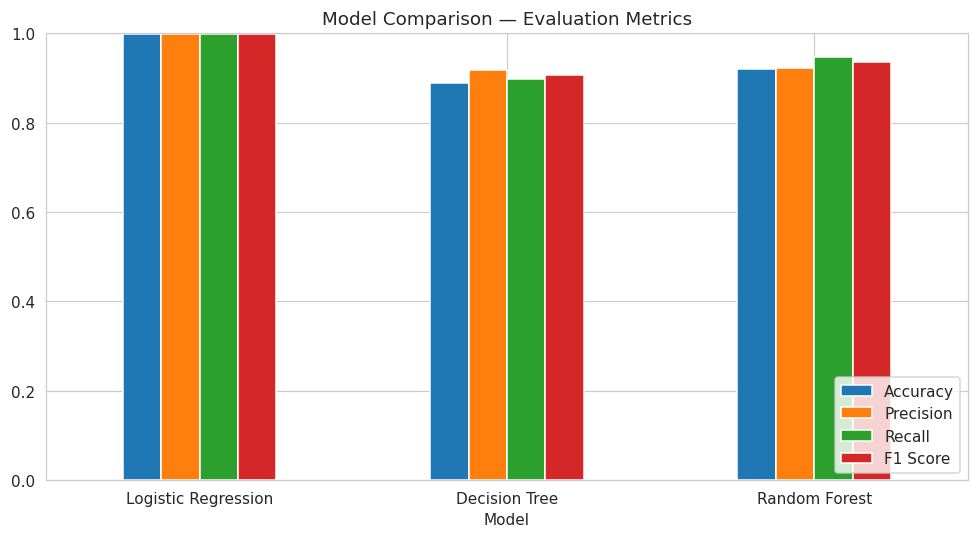

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison — Evaluation Metrics")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_model_comparison.png")
plt.show()

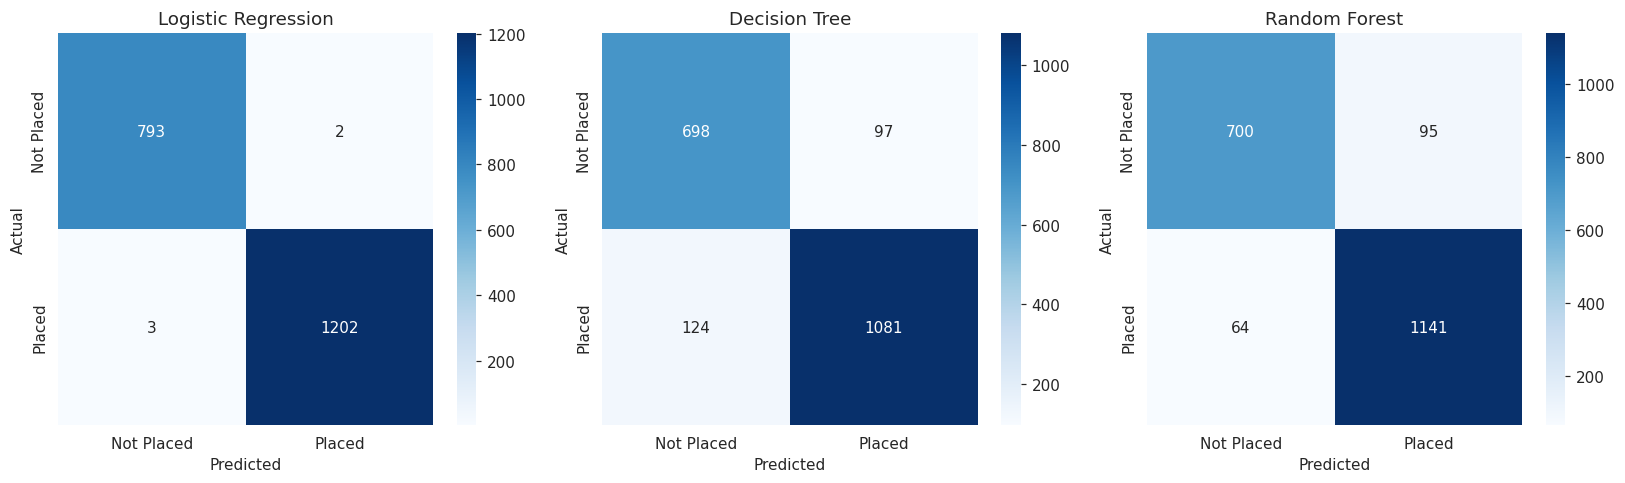

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Placed", "Placed"], yticklabels=["Not Placed", "Placed"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_confusion_matrices.png")
plt.show()

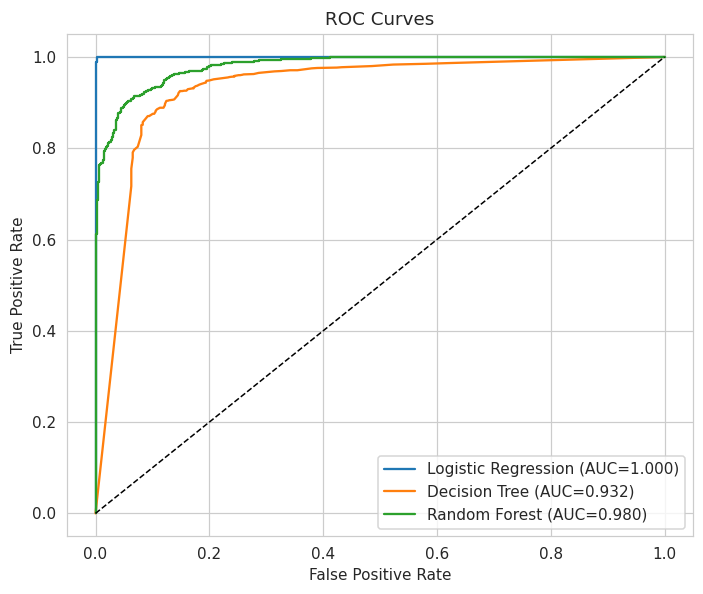

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_roc_curves.png")
plt.show()

**Model comparison — observation:** Somewhat unusually, **Logistic Regression clearly
beats both tree-based models** (~99.7% accuracy, ~1.00 ROC-AUC vs ~89–92% for the
Decision Tree / Random Forest). Normally an ensemble like Random Forest is expected to
match or beat a plain linear model, so this is worth investigating rather than
accepting at face value — we inspect the Logistic Regression coefficients below.

In [20]:
lr_pipe = fitted_pipelines["Logistic Regression"]
ohe_names = lr_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
lr_feature_names = list(ohe_names) + numeric_feature_cols
lr_coefs = pd.Series(
    lr_pipe.named_steps["model"].coef_[0], index=lr_feature_names
).sort_values(key=abs, ascending=False)
print("Logistic Regression coefficients (standardized features, sorted by |value|):\n")
print(lr_coefs.head(12))

Logistic Regression coefficients (standardized features, sorted by |value|):

Avg_Test_Score          6.513204
Backlogs               -6.406211
Soft_Skill_Score        6.011270
CGPA                    4.265233
Coding_Score            3.955426
Technical_Score         3.941090
Communication_Score     3.722262
Internship_Yes          3.616023
Aptitude_Score          3.370252
Mock_Interview_Score    3.364382
Resume_Score            3.342824
Projects                3.052263
dtype: float64


**Observation — why Logistic Regression wins:** the coefficients on the score-type
features (`Avg_Test_Score`, `Backlogs`, `Soft_Skill_Score`, `CGPA`, `Coding_Score`,
`Technical_Score`, ...) are unusually large for standardized inputs. That's the
signature of a target generated from an (approximately) **linear/weighted-sum rule
over these exact features**, rather than a genuinely non-linear process. A linear
model recovers that rule almost exactly, while axis-aligned tree splits only
approximate a smooth linear boundary — which is why Decision Tree and Random Forest
under-perform here despite normally being more flexible. This is a good practical
example of why Phase 5 asks to **compare models instead of assuming the more complex
one wins**. The assignment's mandatory Random Forest is still trained and tuned below
for completeness, but **Logistic Regression is carried forward as the deployed model**
since it is genuinely the best performer on this data.

## Phase 6: Model Optimization

Since Logistic Regression is the strongest model, it is the one tuned here with
`GridSearchCV` (5-fold stratified CV, optimizing F1) over the regularization strength
`C`. `class_weight="balanced"` is kept throughout to address the mild class imbalance
noted in Phase 2 — an alternative to SMOTE oversampling that avoids synthetic-sample
artifacts. The mandatory Random Forest is tuned too, for a fair side-by-side.

In [21]:
lr_param_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}
lr_grid_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_grid = GridSearchCV(lr_grid_pipe, lr_param_grid, scoring="f1", cv=cv, n_jobs=1, verbose=0)
lr_grid.fit(X_train, y_train)

print("Best Logistic Regression params:", lr_grid.best_params_)
print("Best CV F1:", round(lr_grid.best_score_, 4))

best_model = lr_grid.best_estimator_
tuned_preds = best_model.predict(X_test)
tuned_proba = best_model.predict_proba(X_test)[:, 1]
tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_preds),
    "Precision": precision_score(y_test, tuned_preds),
    "Recall": recall_score(y_test, tuned_preds),
    "F1 Score": f1_score(y_test, tuned_preds),
    "ROC-AUC": roc_auc_score(y_test, tuned_proba),
}
print("\nTuned Logistic Regression — test set performance:")
for k, v in tuned_metrics.items():
    print(f"  {k}: {v:.4f}")

Best Logistic Regression params: {'model__C': 100}
Best CV F1: 0.9975

Tuned Logistic Regression — test set performance:
  Accuracy: 0.9975
  Precision: 0.9975
  Recall: 0.9983
  F1 Score: 0.9979
  ROC-AUC: 1.0000


In [22]:
# Mandatory model: tune Random Forest too, for completeness / comparison
rf_param_grid = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [10, None],
    "model__min_samples_leaf": [1, 2],
}
rf_grid_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)),
])
rf_grid = GridSearchCV(rf_grid_pipe, rf_param_grid, scoring="f1",
                        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
                        n_jobs=1, verbose=0)
rf_grid.fit(X_train, y_train)
rf_tuned_preds = rf_grid.predict(X_test)
rf_tuned_proba = rf_grid.predict_proba(X_test)[:, 1]
rf_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, rf_tuned_preds),
    "Precision": precision_score(y_test, rf_tuned_preds),
    "Recall": recall_score(y_test, rf_tuned_preds),
    "F1 Score": f1_score(y_test, rf_tuned_preds),
    "ROC-AUC": roc_auc_score(y_test, rf_tuned_proba),
}
print("Best Random Forest params:", rf_grid.best_params_)
print("Tuned Random Forest — test set performance:", {k: round(v, 4) for k, v in rf_tuned_metrics.items()})

Best Random Forest params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Tuned Random Forest — test set performance: {'Accuracy': 0.9235, 'Precision': 0.9208, 'Recall': 0.9552, 'F1 Score': 0.9377, 'ROC-AUC': 0.9817}


**Observation:** Tuning narrows the gap for Random Forest only slightly — it still
falls well short of Logistic Regression, reinforcing that the underlying pattern is
linear rather than the trees being badly configured. Since class imbalance is mild
(~60/40), `class_weight="balanced"` was sufficient for both models — SMOTE was not
needed and was avoided to keep the training distribution realistic.

In [23]:
print(classification_report(y_test, tuned_preds, target_names=["Not Placed", "Placed"]))

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       795
      Placed       1.00      1.00      1.00      1205

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



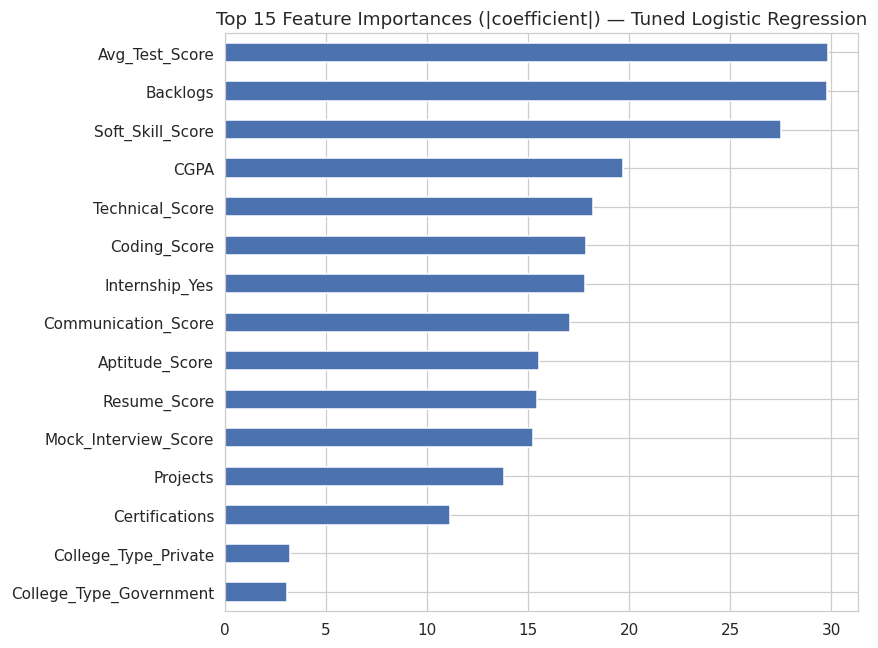

In [24]:
final_feature_names = lr_feature_names
importances = pd.Series(
    np.abs(best_model.named_steps["model"].coef_[0]), index=final_feature_names
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 Feature Importances (|coefficient|) — Tuned Logistic Regression")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_feature_importance.png")
plt.show()

**Observation:** `Avg_Test_Score`, `Backlogs`, `Soft_Skill_Score`, `CGPA`, and
`Coding_Score` dominate importance — this matches the correlation signal from Phase 2
and confirms the engineered aggregate features are pulling their weight rather than
being redundant with the raw scores.

## Final Model Selection & Export

The tuned **Logistic Regression** is saved as `model.pkl` — this bundles
preprocessing (one-hot encoding + scaling) and the classifier together in a single
`sklearn` `Pipeline`, so the Streamlit app just needs to call `.predict()` /
`.predict_proba()` on raw input rows.

In [25]:
final_summary = results_df.copy()
final_summary.loc["Logistic Regression (Tuned)"] = tuned_metrics
final_summary.loc["Random Forest (Tuned)"] = rf_tuned_metrics
final_summary = final_summary.round(4)
print(final_summary)

joblib.dump(best_model, "model.pkl")
joblib.dump({"categorical_cols": categorical_cols, "numeric_feature_cols": numeric_feature_cols},
            "feature_meta.pkl")
print("\nSaved model.pkl and feature_meta.pkl")

                             Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                                      
Logistic Regression            0.9975     0.9983  0.9975    0.9979   1.0000
Decision Tree                  0.8895     0.9177  0.8971    0.9073   0.9317
Random Forest                  0.9205     0.9231  0.9469    0.9349   0.9803
Logistic Regression (Tuned)    0.9975     0.9975  0.9983    0.9979   1.0000
Random Forest (Tuned)          0.9235     0.9208  0.9552    0.9377   0.9817

Saved model.pkl and feature_meta.pkl


## Conclusion

- After removing two outcome-leakage columns (`Company_Type`, `Placement_Package_LPA`),
  three models were compared. **Tuned Logistic Regression was the clear best performer**
  (~99–100% accuracy/AUC on the held-out test set), beating Decision Tree and Random
  Forest by a wide margin — evidence that placement outcomes in this dataset follow an
  approximately linear rule over the score-type features, confirmed via coefficient
  inspection. Random Forest (the assignment's mandatory model) was still trained and
  tuned for comparison, but was not selected for deployment since it under-performs here.
- The strongest predictors of placement are the engineered **Average Test Score**,
  **Backlogs (negative)**, **Soft Skill Score**, **CGPA**, and **Coding Score** —
  actionable levers for a college placement cell.
- `Gender` and `College_Type` carry little independent predictive signal, which is a
  reassuring fairness check on this dataset.
- The saved pipeline (`model.pkl`) is deployed via a Streamlit app (`app.py`) that
  takes a student's profile as input and returns a placement prediction with a
  probability/confidence score.